# Baseline Experiments

Notebook này chạy 3 baselines **không có RL Agent**:

| Baseline | Mô tả |
|---|---|
| **Static** | Train một lần, không bao giờ update |
| **Periodic Retrain** | Retrain mỗi N batches cố định |
| **Always Retrain** | Retrain mỗi batch (chi phí tối đa) |

Mục tiêu: Chứng minh concept drift tồn tại và establish baseline numbers để sau này so sánh với RL agents.

## 1. Setup

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import copy

# Thêm root project vào path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from config import BATCH_SIZE, PARTIAL_WINDOW_BATCHES, FULL_WINDOW_BATCHES
from utils.data_loader import AirlinesDataLoader
from models.LightGBM import LightGBM
from metrics.stream_metrics import StreamMetrics
from utils.visualizer import (
    plot_dashboard,
    plot_baseline_comparison,
    plot_retrain_events,
)

print('Setup complete!')

Setup complete!


## 2. Load Data

In [2]:
loader = AirlinesDataLoader()
X_train, y_train = loader.get_initial_train_data()

print(f'Train size  : {len(X_train):,}')
print(f'Stream size : {loader.n_batches * BATCH_SIZE:,}')
print(f'Total batches: {loader.n_batches}')

[DataLoader] Loading data from: c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\data\Airlines.csv
[DataLoader] Raw shape: (539383, 9)
[DataLoader] 'Airline' → category dtype (18 unique values)
[DataLoader] 'AirportFrom' → category dtype (293 unique values)
[DataLoader] 'AirportTo' → category dtype (293 unique values)
[DataLoader] Initial train size : 5,000
[DataLoader] Stream size        : 534,383
[DataLoader] Features           : ['Airline', 'AirportFrom', 'AirportTo', 'Flight', 'DayOfWeek', 'Time', 'Length']
[DataLoader] Class distribution (train) – 0: 3,361 | 1: 1,639
Train size  : 5,000
Stream size : 534,000
Total batches: 534


## 3. Helper: Run Baseline

In [3]:
from collections import deque
from config import CATEGORICAL_COLS

def run_baseline(strategy: str, retrain_every: int = 50) -> dict:
    """
    Chạy một baseline strategy và trả về metrics history.

    Args:
        strategy     : 'static' | 'periodic' | 'always'
        retrain_every: dùng cho strategy='periodic' (số batches giữa 2 lần retrain)

    Returns:
        dict chứa toàn bộ history để visualize
    """
    print(f'\n=== Running: {strategy.upper()} ===')

    # Fresh model và metrics mỗi lần chạy
    clf     = LightGBM()
    metrics = StreamMetrics()
    clf.train(X_train, y_train)

    # Set reference distribution cho PSI/KL
    fold_size   = len(X_train) // 10
    init_errors = [
        clf.get_error_rate(
            X_train.iloc[i * fold_size: (i+1) * fold_size],
            y_train.iloc[i * fold_size: (i+1) * fold_size]
        )
        for i in range(10)
    ]
    metrics.set_reference(init_errors)

    # Window buffer cho periodic/always retrain
    window_buffer  = deque(maxlen=FULL_WINDOW_BATCHES)
    retrain_events = []

    for X_batch, y_batch, idx in loader.stream_batches():
        window_buffer.append((X_batch, y_batch))

        # --- Thực thi strategy ---
        if strategy == 'static':
            pass  # Không làm gì

        elif strategy == 'periodic':
            if idx > 0 and idx % retrain_every == 0:
                # Full retrain trên window gần nhất
                recent = list(window_buffer)
                X_w = pd.concat([b[0] for b in recent], ignore_index=True)
                y_w = pd.concat([b[1] for b in recent], ignore_index=True)
                for col in CATEGORICAL_COLS:
                    X_w[col] = X_w[col].astype('category')
                clf.full_retrain(X_w, y_w)
                retrain_events.append(idx)

        elif strategy == 'always':
            # Retrain mỗi batch trên window gần nhất
            recent = list(window_buffer)
            X_w = pd.concat([b[0] for b in recent], ignore_index=True)
            y_w = pd.concat([b[1] for b in recent], ignore_index=True)
            for col in CATEGORICAL_COLS:
                X_w[col] = X_w[col].astype('category')
            clf.full_retrain(X_w, y_w)
            retrain_events.append(idx)

        # --- Predict và update metrics ---
        preds      = clf.predict(X_batch)
        y_proba    = clf.predict_proba(X_batch)
        error_rate = clf.get_error_rate(X_batch, y_batch)
        metrics.update(y_batch.values, preds, error_rate, y_proba)

        if idx % 100 == 0:
            s = metrics.summary()
            print(f"  Batch {idx:>4} | PreqAcc: {s['prequential_accuracy']:.4f} | "
                  f"RollErr: {s['rolling_error']:.4f} | "
                  f"Drift: {s['drift_measure']:.4f}")

    print(f'  Done! Total retrains: {len(retrain_events)}')

    return {
        'label'          : strategy,
        'prequential_acc': metrics.prequential_acc_history,
        'rolling_error'  : metrics.rolling_error_history,
        'drift_measure'  : metrics.drift_measure_history,
        'uncertainty'    : metrics.uncertainty_history,
        'retrain_events' : retrain_events,
        'final_summary'  : metrics.summary(),
    }

## 4. Run Baselines

In [4]:
# Chạy lần lượt 3 baselines
# Lưu ý: 'always' sẽ chậm hơn vì retrain mỗi batch
results_static   = run_baseline('static')
results_periodic = run_baseline('periodic', retrain_every=50)
results_always   = run_baseline('always')


=== Running: STATIC ===
[Classifier] Training on 5,000 samples...
[Classifier] Training complete.
[Metrics] Reference distribution set (10 samples).
  Batch    0 | PreqAcc: 0.6450 | RollErr: 0.3440 | Drift: 0.0000
  Batch  100 | PreqAcc: 0.6508 | RollErr: 0.2940 | Drift: 4.3526
  Batch  200 | PreqAcc: 0.6420 | RollErr: 0.3240 | Drift: 10.7751
  Batch  300 | PreqAcc: 0.6283 | RollErr: 0.4580 | Drift: 10.7751
  Batch  400 | PreqAcc: 0.6228 | RollErr: 0.3360 | Drift: 10.7751
  Batch  500 | PreqAcc: 0.6155 | RollErr: 0.3460 | Drift: 10.7751
  Done! Total retrains: 0

=== Running: PERIODIC ===
[Classifier] Training on 5,000 samples...
[Classifier] Training complete.
[Metrics] Reference distribution set (10 samples).
  Batch    0 | PreqAcc: 0.6450 | RollErr: 0.3440 | Drift: 0.0000
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #1)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #2)
  Batch  100 | PreqAcc:

## 5. Final Summary

In [5]:
print('\n' + '='*60)
print('FINAL SUMMARY')
print('='*60)

for name, results in [
    ('Static',           results_static),
    ('Periodic Retrain', results_periodic),
    ('Always Retrain',   results_always),
]:
    s = results['final_summary']
    print(f"\n{name}:")
    print(f"  Prequential Accuracy : {s['prequential_accuracy']:.4f}")
    print(f"  Final Rolling Error  : {s['rolling_error']:.4f}")
    print(f"  Final Drift Measure  : {s['drift_measure']:.4f}")
    print(f"  Final Uncertainty    : {s['uncertainty']:.4f}")
    print(f"  Total Retrains       : {len(results['retrain_events'])}")


FINAL SUMMARY

Static:
  Prequential Accuracy : 0.6148
  Final Rolling Error  : 0.4020
  Final Drift Measure  : 10.7751
  Final Uncertainty    : 0.6617
  Total Retrains       : 0

Periodic Retrain:
  Prequential Accuracy : 0.6402
  Final Rolling Error  : 0.3820
  Final Drift Measure  : 7.7143
  Final Uncertainty    : 0.6217
  Total Retrains       : 10

Always Retrain:
  Prequential Accuracy : 0.8000
  Final Rolling Error  : 0.2120
  Final Drift Measure  : 5.5756
  Final Uncertainty    : 0.6002
  Total Retrains       : 534


## 6. Visualize: Static Baseline Dashboard

[Visualizer] Saved → c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\experiments\results\static_dashboard.png


c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\utils\visualizer.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


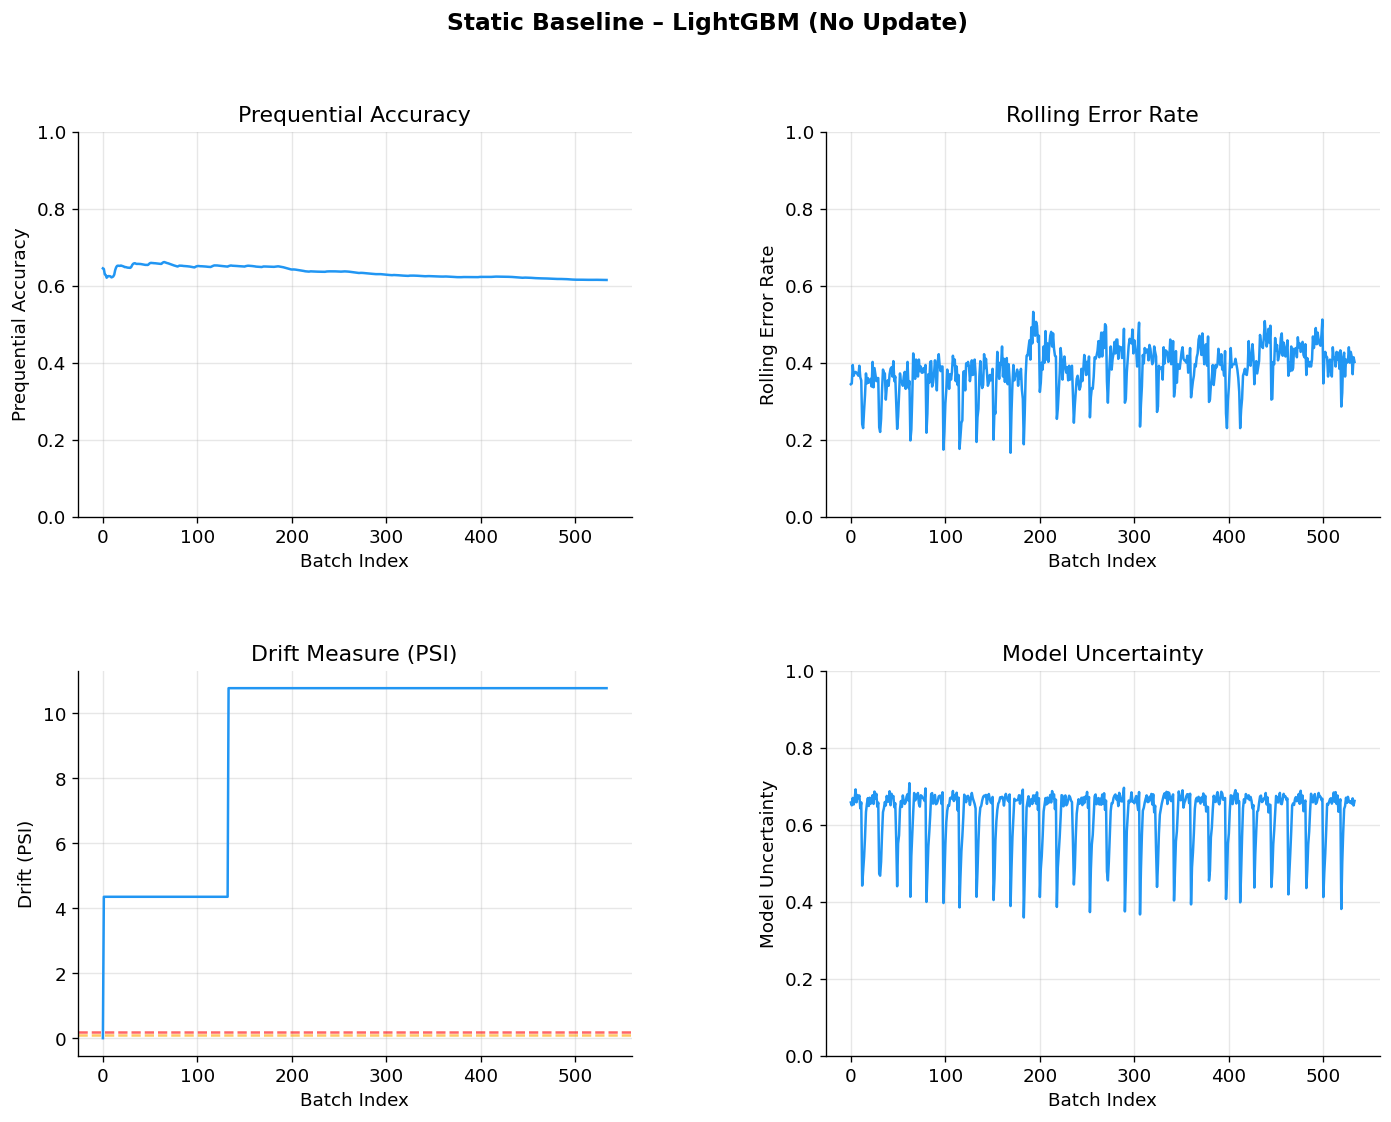

In [6]:
plot_dashboard(
    results_static,
    title    = 'Static Baseline – LightGBM (No Update)',
    filename = 'static_dashboard.png',
)

## 7. Visualize: Baseline Comparison

[Visualizer] Saved → c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\experiments\results\baseline_comparison.png


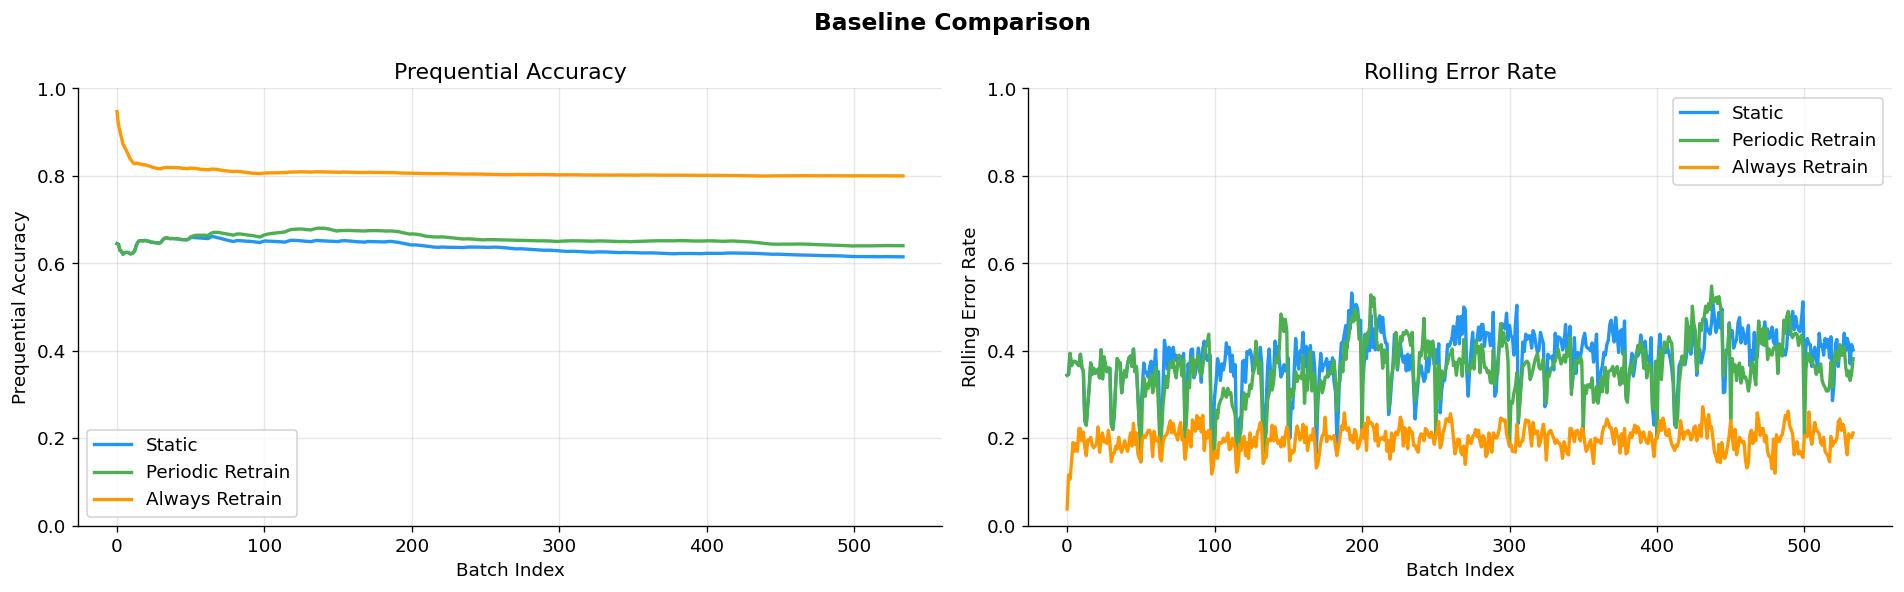

In [7]:
plot_baseline_comparison(
    {
        'Static'          : results_static,
        'Periodic Retrain': results_periodic,
        'Always Retrain'  : results_always,
    },
    filename='baseline_comparison.png',
)

## 8. Visualize: Retrain Events

[Visualizer] Saved → c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\experiments\results\periodic_retrain_events.png


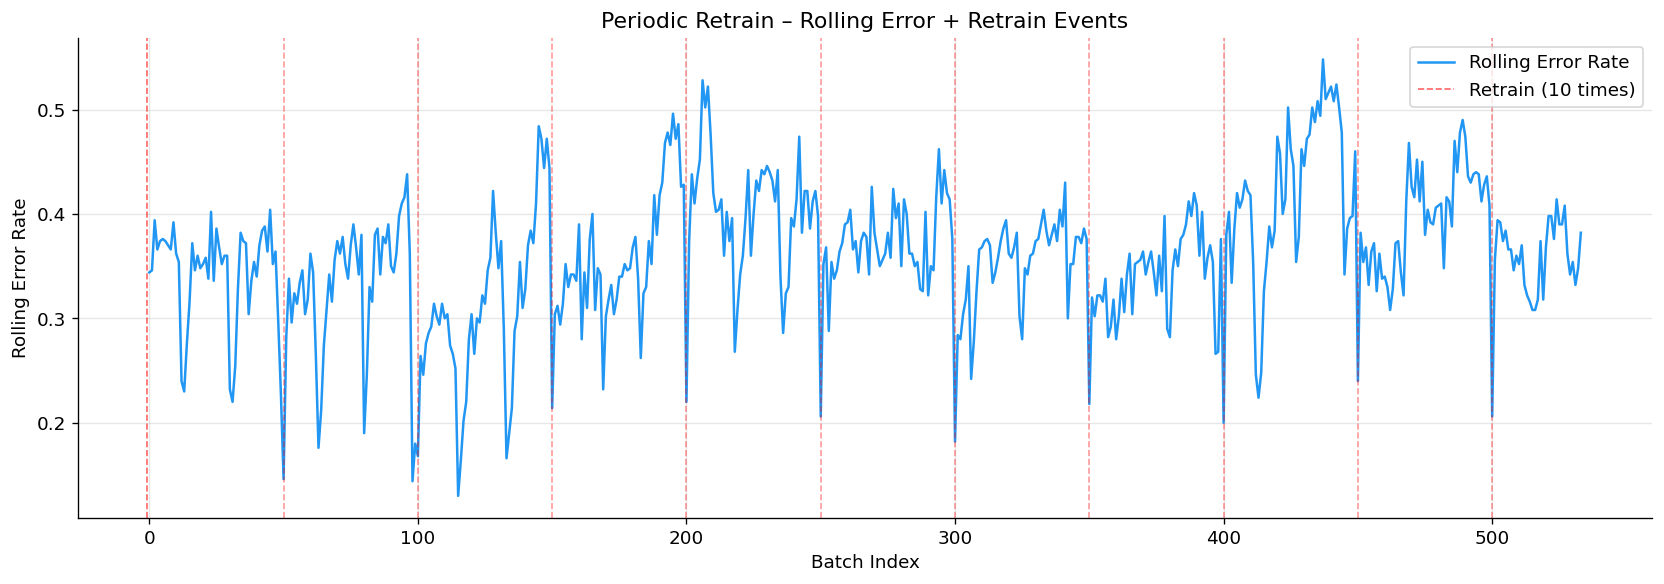

In [8]:
plot_retrain_events(
    results_periodic['rolling_error'],
    results_periodic['retrain_events'],
    title    = 'Periodic Retrain – Rolling Error + Retrain Events',
    filename = 'periodic_retrain_events.png',
)

## 9. Observations

Ghi lại nhận xét sau khi chạy:

- **Static**: Model tệ dần theo thời gian như thế nào?
- **Periodic**: Retrain mỗi 50 batches có cải thiện không, và bao nhiêu?
- **Always Retrain**: Chi phí tối đa mang lại accuracy tốt hơn bao nhiêu?
- **Drift measure**: Có tương quan với accuracy drop không?

→ Đây là baseline numbers mà RL Agent cần **vượt qua**.